In [2]:
import sys
print(sys.executable)

c:\Users\USER\AppData\Local\Programs\Python\Python311\python.exe


In [3]:
import sys
!{sys.executable} -m pip install ucimlrepo


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from ucimlrepo import fetch_ucirepo

print("ucimlrepo imported successfully!")

ucimlrepo imported successfully!


In [5]:
from ucimlrepo import fetch_ucirepo

# Fetch UCI Student Performance dataset
student_performance = fetch_ucirepo(id=320)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [6]:
X = student_performance.data.features
y = student_performance.data.targets

print("Features shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())
display(y.head())

Features shape: (649, 30)
Target shape: (649, 3)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,yes,no,no,4,3,4,1,1,3,4
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,yes,no,5,3,3,1,1,3,2
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,yes,no,4,3,2,2,3,3,6
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,yes,3,2,2,1,1,5,0
4,GP,F,16,U,GT3,T,3,3,other,other,...,yes,no,no,4,3,2,1,2,5,0


,G1,G2,G3
0,0,11,11
1,9,11,11
2,12,13,12
3,14,14,14
4,11,13,13


In [7]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 30 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non-null    str  
 20  higher      649 non-null    str  
 21  inte

In [8]:
print("Target column:")
display(y.head(10))

print("\nTarget information:")
y.info()

print("\nTarget statistics:")
display(y.describe())

Target column:


,G1,G2,G3
0,0,11,11
1,9,11,11
2,12,13,12
3,14,14,14
4,11,13,13
5,12,12,13
6,13,12,13
7,10,13,13
8,15,16,17
9,12,12,13



Target information:
<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   G1      649 non-null    int64
 1   G2      649 non-null    int64
 2   G3      649 non-null    int64
dtypes: int64(3)
memory usage: 15.3 KB

Target statistics:


,G1,G2,G3
count,649.000000,649.000000,649.000000
mean,11.399076,11.570108,11.906009
std,2.745265,2.913639,3.230656
min,0.000000,0.000000,0.000000
25%,10.000000,10.000000,10.000000
50%,11.000000,11.000000,12.000000
75%,13.000000,13.000000,14.000000
max,19.000000,19.000000,19.000000


In [9]:
print(y["G3"].value_counts().sort_index())

G3
0      15
1       1
5       1
6       3
7      10
8      35
9      35
10     97
11    104
12     72
13     82
14     63
15     49
16     36
17     29
18     15
19      2
Name: count, dtype: int64


In [10]:
risk_target = y["G3"].apply(
    lambda grade: "At-Risk" if grade < 10 else "Not-At-Risk"
)

print(risk_target.value_counts())

G3
Not-At-Risk    549
At-Risk        100
Name: count, dtype: int64


In [11]:
print("Class counts:")
print(risk_target.value_counts())

print("\nClass percentages:")
print(risk_target.value_counts(normalize=True) * 100)


Class counts:
G3
Not-At-Risk    549
At-Risk        100
Name: count, dtype: int64

Class percentages:
G3
Not-At-Risk    84.59168
At-Risk        15.40832
Name: proportion, dtype: float64


In [12]:
print(X.columns.tolist())

['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']


In [13]:
print(y.columns.tolist())

['G1', 'G2', 'G3']


In [14]:
X_early = X.copy()
y_risk = risk_target

print("X shape:", X_early.shape)
print("y shape:", y_risk.shape)

X shape: (649, 30)
y shape: (649,)


In [15]:
import sys
!{sys.executable} -m pip install scikit-learn


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_early,
    y_risk,
    test_size=0.20,
    random_state=42,
    stratify=y_risk
)

print("Training students:", len(X_train))
print("Testing students:", len(X_test))

print("\nTraining classes:")
print(y_train.value_counts())

print("\nTesting classes:")
print(y_test.value_counts())

Training students: 519
Testing students: 130

Training classes:
G3
Not-At-Risk    439
At-Risk         80
Name: count, dtype: int64

Testing classes:
G3
Not-At-Risk    110
At-Risk         20
Name: count, dtype: int64


In [17]:
print("X exists:", "X" in globals())
print("risk_target exists:", "risk_target" in globals())
print("X_early exists:", "X_early" in globals())
print("X_train exists:", "X_train" in globals())

X exists: True
risk_target exists: True
X_early exists: True
X_train exists: True


In [18]:
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()
numerical_cols = X_train.select_dtypes(include="number").columns.tolist()

print("Categorical features:")
print(categorical_cols)

print("\nNumerical features:")
print(numerical_cols)

print("\nNumber of categorical features:", len(categorical_cols))
print("Number of numerical features:", len(numerical_cols))

Categorical features:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Numerical features:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']

Number of categorical features: 17
Number of numerical features: 13


C:\Users\USER\AppData\Local\Temp\ipykernel_26984\2554123774.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include="object").columns.tolist()


In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numerical_cols)
    ]
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [20]:
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

baseline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(strategy="most_frequent"))
])

baseline.fit(X_train, y_train)

baseline_predictions = baseline.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, baseline_predictions))

print("Recall:",
      recall_score(
          y_test,
          baseline_predictions,
          pos_label="At-Risk",
          zero_division=0
      ))

print("Precision:",
      precision_score(
          y_test,
          baseline_predictions,
          pos_label="At-Risk",
          zero_division=0
      ))

print("F1:",
      f1_score(
          y_test,
          baseline_predictions,
          pos_label="At-Risk",
          zero_division=0
      ))

Accuracy: 0.8461538461538461
Recall: 0.0
Precision: 0.0
F1: 0.0


Build the SVM

In [21]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

svm_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", SVC())
])

svm_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['At-Risk','Not-At-Risk']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['school','sex','age',...,'Walc','health','absences']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'

In [22]:
svm_predictions = svm_model.predict(X_test)

print(svm_predictions[:10])

['Not-At-Risk' 'Not-At-Risk' 'Not-At-Risk' 'Not-At-Risk' 'At-Risk'
 'Not-At-Risk' 'Not-At-Risk' 'Not-At-Risk' 'Not-At-Risk' 'Not-At-Risk']


In [23]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

svm_accuracy = accuracy_score(y_test, svm_predictions)

svm_recall = recall_score(
    y_test, svm_predictions,
    pos_label="At-Risk"
)

svm_precision = precision_score(
    y_test, svm_predictions,
    pos_label="At-Risk"
)

svm_f1 = f1_score(
    y_test, svm_predictions,
    pos_label="At-Risk"
)

print("SVM Accuracy :", svm_accuracy)
print("SVM Recall   :", svm_recall)
print("SVM Precision:", svm_precision)
print("SVM F1 Score :", svm_f1)

SVM Accuracy : 0.8307692307692308
SVM Recall   : 0.15
SVM Precision: 0.375
SVM F1 Score : 0.21428571428571427


In [25]:
import sys
!{sys.executable} -m pip install matplotlib

  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/66/54/91fe3fdfa29100b4668cbf9721577a10acde6e009694618230e4e7a97527/matplotlib-3.11.2-cp311-cp311-win_amd64.whl.metadata
     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     -------------- ----------------------- 30.7/80.3 kB 217.9 kB/s eta 0:00:01
     ------------------- ------------------ 41.0/80.3 kB 217.9 kB/s eta 0:00:01
     ----------------------------- -------- 61.4/80.3 kB 273.8 kB/s eta 0:00:01
     -------------------------------------- 80.3/80.3 kB 280.1 kB/s eta 0:00:00
  Obtaining dependency information for contourpy>=1.0.1 from https://files.pythonhosted.org/packages/98/4b/9bd370b004b5c9d8045c6c33cf65bae018b27aca550a3f657cdc99acdbd8/contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency infor

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Matplotlib is building the font cache; this may take a moment.


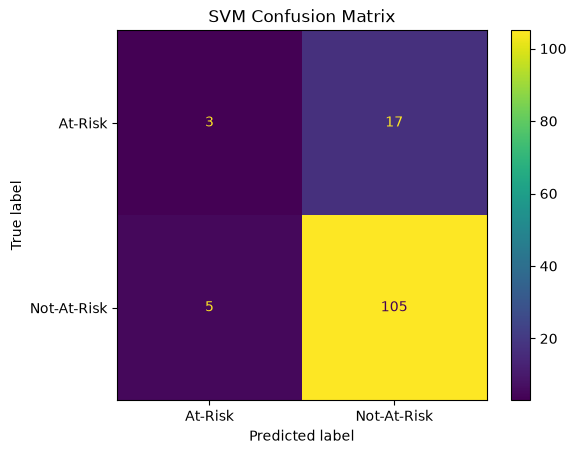

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    svm_predictions,
    labels=["At-Risk", "Not-At-Risk"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["At-Risk", "Not-At-Risk"]
)

disp.plot()
plt.title("SVM Confusion Matrix")
plt.show()

In [28]:
from sklearn.model_selection import cross_val_score

svm_cv_scores = cross_val_score(
    svm_model,
    X_train,
    y_train,
    cv=5,
    scoring="recall_macro"
)

print("SVM CV Recall Scores:", svm_cv_scores)
print("SVM Mean CV Recall:", svm_cv_scores.mean())

SVM CV Recall Scores: [0.52556818 0.65625    0.60795455 0.61931818 0.60775862]
SVM Mean CV Recall: 0.6033699059561128


In [29]:
from sklearn.model_selection import GridSearchCV

svm_param_grid = {
    "classifier__C": [0.1, 1, 10],
    "classifier__kernel": ["linear", "rbf"],
    "classifier__class_weight": [None, "balanced"]
}

svm_grid = GridSearchCV(
    svm_model,
    svm_param_grid,
    cv=5,
    scoring="recall_macro",
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

print("Best Parameters:", svm_grid.best_params_)
print("Best CV Recall:", svm_grid.best_score_)

Best Parameters: {'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__kernel': 'rbf'}
Best CV Recall: 0.7877677638453501


In [30]:
best_svm = svm_grid.best_estimator_

tuned_svm_predictions = best_svm.predict(X_test)

print("Tuned SVM Accuracy :", accuracy_score(y_test, tuned_svm_predictions))
print("Tuned SVM Recall   :", recall_score(
    y_test, tuned_svm_predictions, pos_label="At-Risk"
))
print("Tuned SVM Precision:", precision_score(
    y_test, tuned_svm_predictions, pos_label="At-Risk"
))
print("Tuned SVM F1 Score :", f1_score(
    y_test, tuned_svm_predictions, pos_label="At-Risk"
))

Tuned SVM Accuracy : 0.6538461538461539
Tuned SVM Recall   : 0.55
Tuned SVM Precision: 0.23404255319148937
Tuned SVM F1 Score : 0.3283582089552239


In [31]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline

gb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=42))
])

gb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['At-Risk','Not-At-Risk']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['school','sex','age',...,'Walc','health','absences']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'

In [32]:
gb_predictions = gb_model.predict(X_test)

gb_accuracy = accuracy_score(y_test, gb_predictions)
gb_recall = recall_score(
    y_test, gb_predictions,
    pos_label="At-Risk"
)
gb_precision = precision_score(
    y_test, gb_predictions,
    pos_label="At-Risk"
)
gb_f1 = f1_score(
    y_test, gb_predictions,
    pos_label="At-Risk"
)

print("Gradient Boosting Accuracy :", gb_accuracy)
print("Gradient Boosting Recall   :", gb_recall)
print("Gradient Boosting Precision:", gb_precision)
print("Gradient Boosting F1 Score :", gb_f1)

Gradient Boosting Accuracy : 0.7846153846153846
Gradient Boosting Recall   : 0.2
Gradient Boosting Precision: 0.25
Gradient Boosting F1 Score : 0.2222222222222222


In [33]:
gb_param_grid = {
    "classifier__n_estimators": [50, 100, 200],
    "classifier__learning_rate": [0.05, 0.1, 0.2],
    "classifier__max_depth": [1, 2, 3]
}

gb_grid = GridSearchCV(
    gb_model,
    gb_param_grid,
    cv=5,
    scoring="recall_macro",
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

print("Best Parameters:", gb_grid.best_params_)
print("Best CV Recall:", gb_grid.best_score_)

Best Parameters: {'classifier__learning_rate': 0.2, 'classifier__max_depth': 3, 'classifier__n_estimators': 50}
Best CV Recall: 0.7135971786833857
